['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_adcSection', '_cacheStimulusFiles', '_dacSection', '_dataGain', '_dataOffset', '_dataSection', '_dtype', '_epochPerDacSection', '_epochSection', '_fileGUID', '_fileSize', '_getAdcNameAndUnits', '_getDacNameAndUnits', '_headerV2', '_ide_helper', '_loadAndScaleData', '_makeAdditionalVariables', '_nDataFormat', '_preLoadData', '_protocolSection', '_readHeadersV1', '_readHeadersV2', '_stringsSection', '_sweepBaselinePoints', '_synchArraySection', '_tagSection', '_userListSection', 'abfDateTime', 'abfDateTimeString', 'abfFileComment', 'abfFilePath', 'abfFolderPath', 'abfID', 'abfVersion', 'a

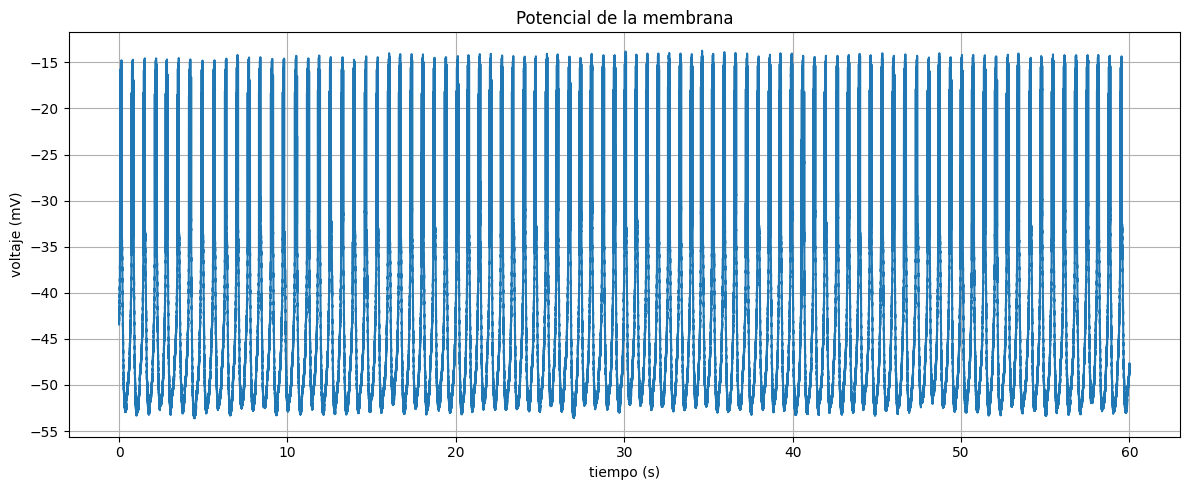

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pyabf

# --- cargar archivo abf ---
ruta = "STG_PD_Bursts.abf"
abf = pyabf.ABF(ruta)

print(dir(abf))

# --- extraer datos ---
voltaje = abf.sweepY          # vector de voltaje (mV)
tiempo = abf.sweepX           # vector de tiempo (s)

# --- gráficas ---
plt.figure(figsize=(12, 5))
plt.plot(tiempo, voltaje)
plt.xlabel("tiempo (s)")
plt.ylabel("voltaje (mV)")
plt.title("Potencial de la membrana")
plt.grid(True)
plt.tight_layout()
plt.show()

2. Identifique los spikes y grafíquelos encima de la gráfica anterior. Dado que la señal puede poseer ruido que haga aparecer pico espurios, verifique cómo el argumento *prominence* y *distance* de la función find_peaks puede ayudarle

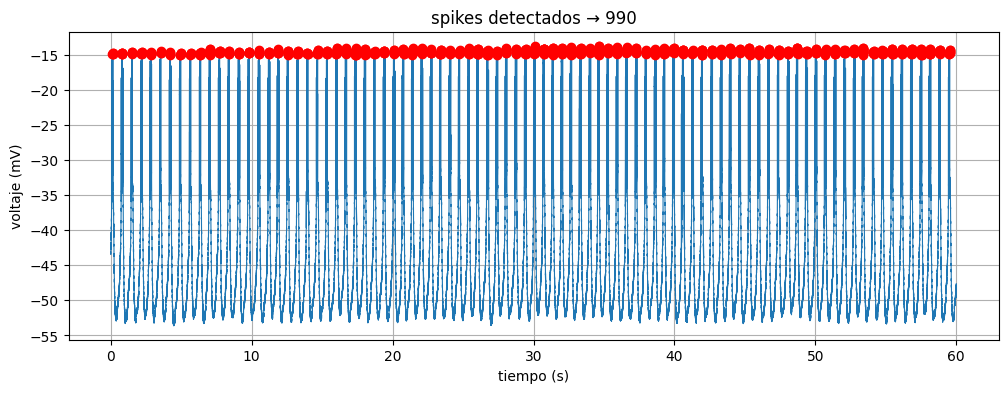

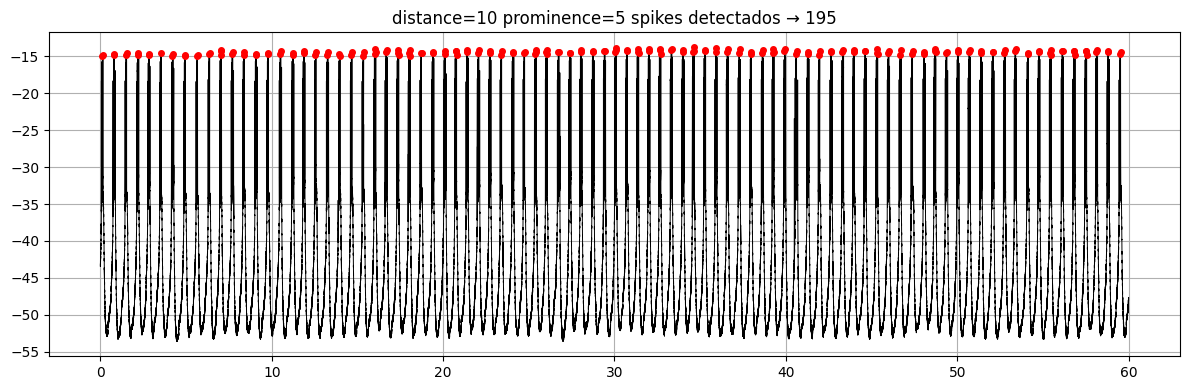

In [42]:
from scipy.signal import find_peaks

prominence = 5
distance = 10
speak_range = -15 # mV

# --- detección de picos ---
speaks, props = find_peaks(voltaje, height=speak_range)

plt.figure(figsize=(12,4))
plt.plot(tiempo, voltaje, lw=0.8)
plt.plot(tiempo[speaks], voltaje[speaks], "ro")
plt.xlabel("tiempo (s)")
plt.ylabel("voltaje (mV)")
plt.title(f"spikes detectados → {len(speaks)}")
plt.grid(True)
plt.show()

spikes, _ = find_peaks(voltaje, prominence=prominence, distance=distance, height=speak_range)

plt.figure(figsize=(12,4))
plt.plot(tiempo, voltaje, lw=0.7, color="black")
plt.plot(tiempo[spikes], voltaje[spikes], "ro", ms=4)

plt.title(f"distance={distance} prominence={prominence} spikes detectados → {len(spikes)}")
plt.grid(True)
plt.tight_layout()
plt.show()


3. Haga el siguiente análisis de la señal:
    - Calcule el histograma del ISI.
    - Cuál es la frecuencia de disparo intra-burst?
    - Cuál es el tiempo promedio inter-burst?
    - Calcule el Coeficiente de Variación del ISI. $CV(ISI) = \frac{\sigma(ISI)}{\langle ISI \rangle}$

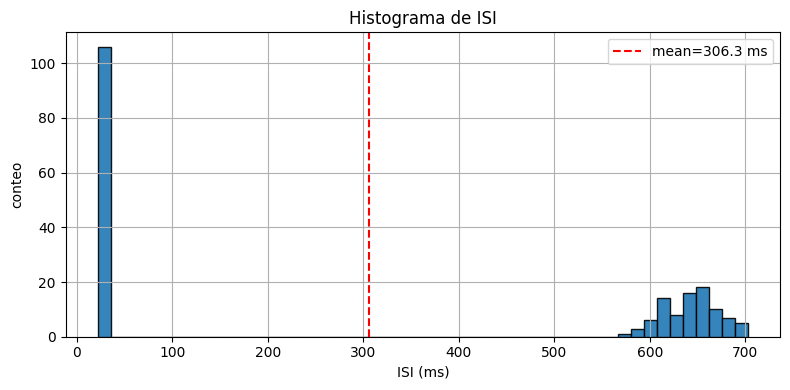

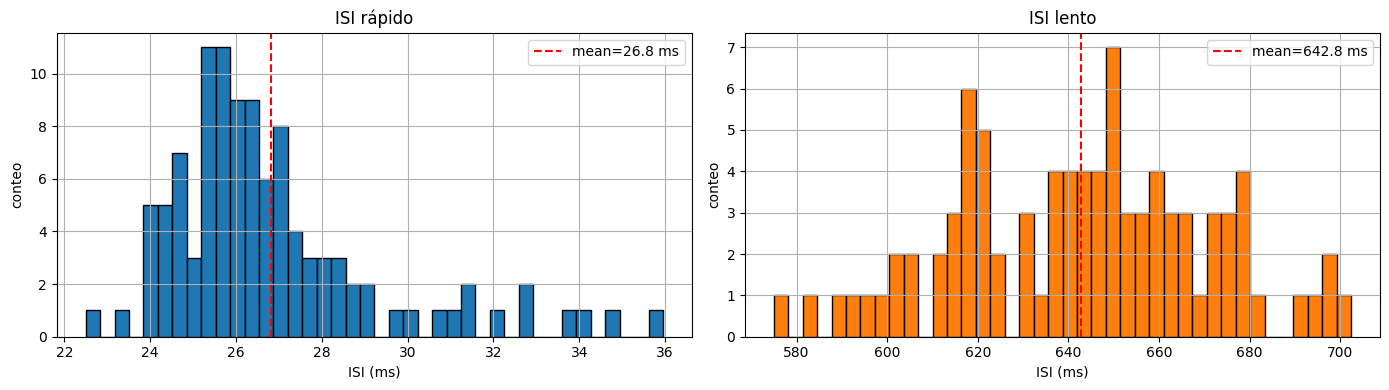

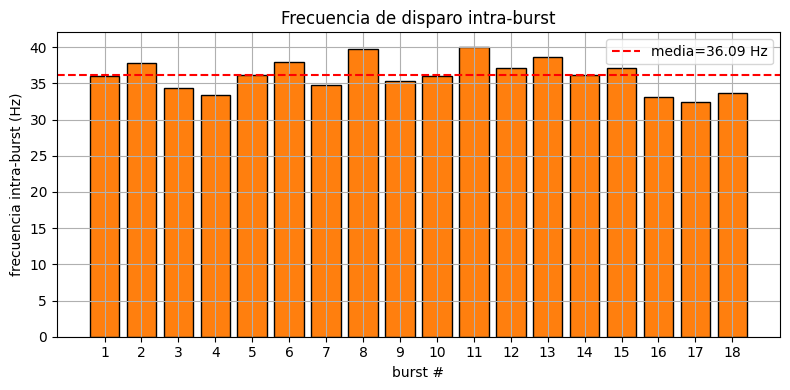

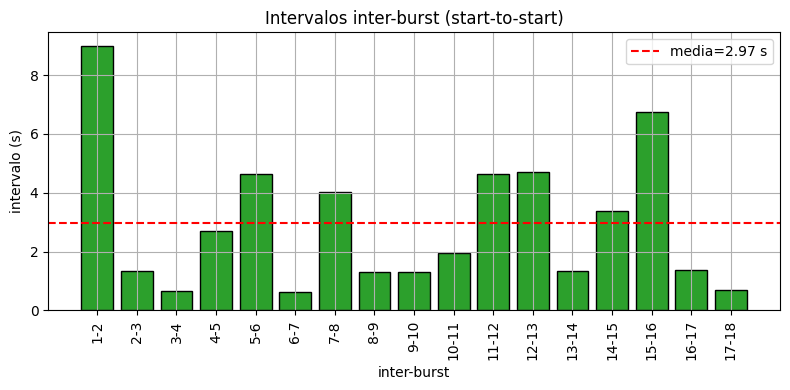

n_spikes = 195
n_bursts = 18
intra_burst_rates (Hz) = [np.float64(35.971223021582674), np.float64(37.77148253068992), np.float64(34.39380911436077), np.float64(33.33333333333207), np.float64(36.101083032489456), np.float64(37.914691943128226), np.float64(34.78260869565372), np.float64(39.80099502487411), np.float64(35.27336860670237), np.float64(36.06853020739376), np.float64(40.04004004004365), np.float64(37.071362372566924), np.float64(38.5728061716477), np.float64(36.16636528028765), np.float64(37.071362372566924), np.float64(33.057851239670754), np.float64(32.41491085899789), np.float64(33.72681281618867)]
inter_burst_intervals (s) = [9.0054 1.3326 0.6733 ... 6.7456 1.378  0.6802]
CV(ISI) = 1.0033 (mean ISI = 306.25 ms, std = 307.26 ms)


In [ ]:
# ---------- detectar spikes ----------
spikes, props = find_peaks(
    voltaje,
    prominence=prominence,
    distance=distance,
    height=speak_range
)

spike_times = tiempo[spikes]  # Tiempos en los que sucedieron spikes

# ---------- ISI ----------
# np.diff hace lo que hace  [spike_times[i+1] - spike_times[i] for i in range(len(spike_times)-1)]
# DeltaT = t_n - t_(n-1) Esta definición sirve para hacer el experimento de impulso pareado (paired-pulse)

# Intérvalos inter-spike => DeltaT = t_n - t_(n-1)
isis = np.diff(spike_times)

# ---------- Detectar bursts ----------
bursts = []
current_count = 1
burst_isi_thresh = 0.1   # Para saber si dos spikes pertenecen al mismo burst (s)
min_spikes_in_burst = 3  # mínimo de spikes para considerar una secuencia como burst

# Obtenemos el índice de cada ISI y su valor
for i, isi in enumerate(isis):

    # Si el isi es menor al tresh definido, decimos que seguimos en el mismo burst
    if isi < burst_isi_thresh:
        current_count += 1

    # Si no seguimos en el mismo burst hasta ahí terminó ese burst y lo guardamos
    else:
        # Para ser un burst tiene que tener al menos min_spikes_in_burst spikes
        if current_count >= min_spikes_in_burst:
            start_burst_index = i + 1 - current_count
            end_burst_index = i
            bursts.append({
                'start_idx': start_burst_index,                 # índice del spike inicial del burst
                'end_idx': end_burst_index,                     # índice del spike final del burst
                'start_time': spike_times[start_burst_index],   # tiempo del spike inicial del burst
                'end_time': spike_times[end_burst_index],       # tiempo del spike final del burst
                'spike_times': spike_times[start_burst_index:end_burst_index+1] # vector de tiempos de spikes del burst
            })
        current_count = 1

# ---------- métricas ----------
isi_mean = np.mean(isis)
isi_std = np.std(isis, ddof=0)   # ddof=0 para N - 0 (Desviación estándar poblacional)
cv_isi = isi_std / isi_mean

# Frecuencia intra-burst x burst (Hz)
# La frecuencia intra-burst, es la media de isis dentro de cada burst
intra_burst_rates = []

# Calculamos la media de ISI para cada intérvalo de burst
for burst in bursts:
    st = burst['spike_times']
    if len(st) < 2:
        intra_burst_rates.append(np.nan)
    else:
        mean_isi_b = np.mean(np.diff(st))
        intra_burst_rates.append(1.0/mean_isi_b if mean_isi_b>0 else np.nan)

# Inter-burst intervals (start-to-start)
# Para cada burst, calculamos la diferencia entre el inicio de un burst y el inicio del siguiente
burst_starts = np.array([burst['start_time'] for burst in bursts])
inter_burst_intervals = np.diff(burst_starts)

# ---------- Graficas ----------

# Histograma de ISI
plt.figure(figsize=(8,4))
plt.hist(isis*1000, bins=50, color='C0', edgecolor='k', alpha=0.9)
plt.axvline(isi_mean*1000, color='r', linestyle='--', label=f"mean={isi_mean*1000:.1f} ms")
plt.xlabel("ISI (ms)")
plt.ylabel("conteo")
plt.title("Histograma de ISI")
plt.legend()
plt.grid(True)
plt.tight_layout()

# separar ISI rápidos e ISI lentos
isi_fast = isis[isis < burst_isi_thresh] * 1000
isi_low = isis[isis >= burst_isi_thresh] * 1000

plt.figure(figsize=(14,4))

# --- histograma isi rápido ---
plt.subplot(1,2,1)
plt.hist(isi_fast, bins=40, color='C0', edgecolor='k')
if len(isi_fast) > 0:
    plt.axvline(np.mean(isi_fast), color='r', linestyle='--',
                label=f"mean={np.mean(isi_fast):.1f} ms")
plt.title("ISI rápido")
plt.xlabel("ISI (ms)")
plt.ylabel("conteo")
plt.grid(True)
plt.legend()

# --- histograma isi lento ---
plt.subplot(1,2,2)
plt.hist(isi_low, bins=40, color='C1', edgecolor='k')
if len(isi_low) > 0:
    plt.axvline(np.mean(isi_low), color='r', linestyle='--',
                label=f"mean={np.mean(isi_low):.1f} ms")
plt.title("ISI lento")
plt.xlabel("ISI (ms)")
plt.ylabel("conteo")
plt.grid(True)
plt.legend()

plt.tight_layout()

# Barra de frecuencias intra-burst
x = np.arange(1, len(intra_burst_rates) + 1) # etiquetas para el eje x
plt.figure(figsize=(8,4))
plt.bar(np.arange(1, len(intra_burst_rates)+1), intra_burst_rates, color='C1', edgecolor='k')
plt.axhline(np.nanmean(intra_burst_rates), color='r', linestyle='--', label=f"media={np.nanmean(intra_burst_rates):.2f} Hz")
plt.xlabel("burst #")
plt.xticks(x, x)
plt.ylabel("frecuencia intra-burst (Hz)")
plt.title("Frecuencia de disparo intra-burst")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Barra de intervalos inter-burst
x = np.arange(1, len(inter_burst_intervals) + 1)
labels = [f"{i}-{i+1}" for i in x]
plt.figure(figsize=(8,4))
plt.bar(np.arange(1, len(inter_burst_intervals)+1), inter_burst_intervals, color='C2', edgecolor='k')
plt.axhline(np.mean(inter_burst_intervals), color='r', linestyle='--', label=f"media={np.mean(inter_burst_intervals):.2f} s")
plt.xlabel("inter-burst")
plt.xticks(x, labels, rotation=90)
plt.ylabel("intervalo (s)")
plt.title("Intervalos inter-burst (start-to-start)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

# ---------- imprimir resultados resumidos ----------
print("n_spikes =", len(spike_times))
print("n_bursts =", len(bursts))
print("intra_burst_rates (Hz) =", intra_burst_rates)
print("inter_burst_intervals (s) =", inter_burst_intervals)
print(f"CV(ISI) = {cv_isi:.4f} (mean ISI = {isi_mean*1000:.2f} ms, std = {isi_std*1000:.2f} ms)")


4. Extraiga el tren de spikes dividiendo el tiempo del experimento en intervalos de tiempo $\Delta t = 20$ms y poniendo un 1 en los intervalos donde hay spikes y 0 donde no los hay y calcule
    - La función de autocorrelación del tren de spikes
    - Le densidad de potencia espectral

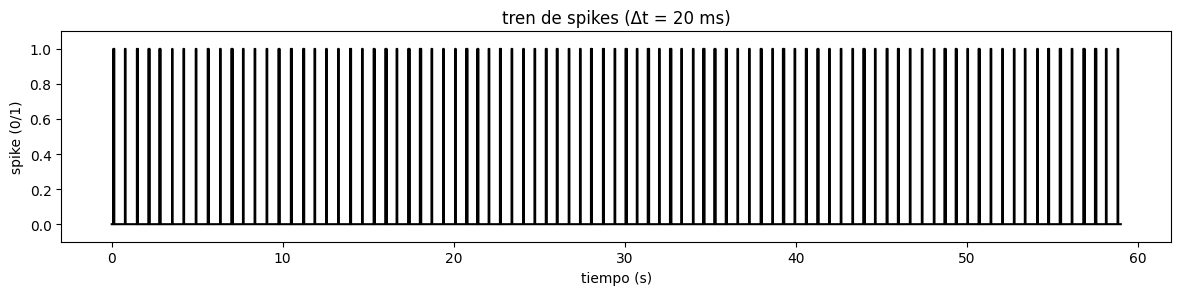

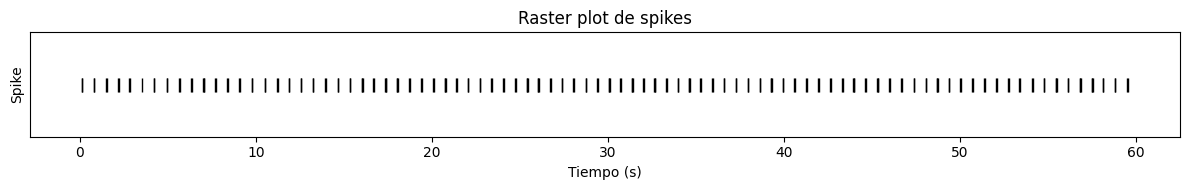

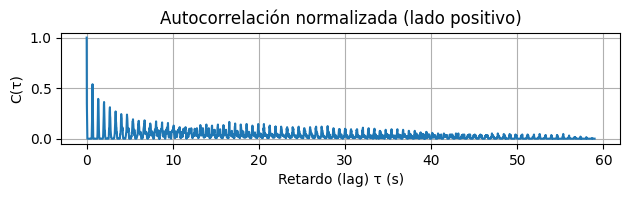

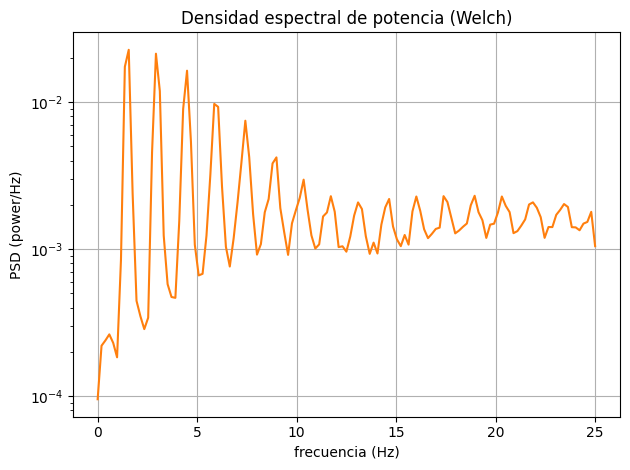

In [52]:
from scipy.signal import welch, correlate

spike_times = tiempo[spikes] # Tiempos en los que sucedieron spikes

dt_bin = 0.02            # s  (20 ms)
T_total = tiempo[-1]     # Tiempo total del experimento
fs_bin = 1.0 / dt_bin    # frecuencia de muestreo

N_bins = int((T_total + dt_bin - 1) // dt_bin)
spike_train = np.array([0] * N_bins)  # array de 0 dividido en bins de 20ms

for i in range(N_bins):
    inicio = i * dt_bin
    fin = inicio + dt_bin

    for st in spike_times:
        if inicio <= st < fin:
            spike_train[i] = 1
            break

# eje temporal para los bins (centros)
bin_centers = []  # lista vacía
for i in range(N_bins):
    centro = i * dt_bin + dt_bin / 2.0
    bin_centers.append(centro)

# ---- Función de autocorrelación ----
autocorr = correlate(spike_train, spike_train, mode='full')
autocorr = autocorr[len(autocorr)//2:]  # Tomar solo la mitad positiva
autocorr = autocorr / autocorr[0] # Normalizar

# Crear eje de tiempo para autocorrelación
tau = np.arange(len(autocorr)) * dt_bin

# ---- Densidad espectral de potencia (PSD) ----
frequencies, power_spectrum = welch(spike_train, fs=fs_bin, nperseg=min(256, len(spike_train)//4))

# Trenes de spikes

plt.figure(figsize=(12,8))
plt.subplot(3,1,1)
plt.plot(bin_centers, spike_train, drawstyle='steps-mid', color='k')
plt.ylim(-0.1, 1.1)
plt.xlabel('tiempo (s)')
plt.ylabel('spike (0/1)')
plt.title('tren de spikes (Δt = 20 ms)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 2))
plt.plot(spike_times, np.ones_like(spike_times), '|', color='k', markersize=10)
plt.xlabel('Tiempo (s)')
plt.ylabel('Spike')
plt.title('Raster plot de spikes')
plt.ylim(0.5, 1.5)
plt.yticks([])
plt.tight_layout()
plt.show()

# Función de autocorrelación
plt.subplot(3,1,2)
plt.plot(tau, autocorr, color='C0')
plt.xlabel('Retardo (lag) τ (s)')
plt.ylabel('C(τ)')
plt.title('Autocorrelación normalizada (lado positivo)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Densidad espectral de potencia
plt.semilogy(frequencies, power_spectrum, color='C1')
plt.xlabel('frecuencia (Hz)')
plt.ylabel('PSD (power/Hz)')
plt.title('Densidad espectral de potencia (Welch)')
plt.grid(True)
plt.tight_layout()
plt.show()

## Ejercicio 2

La siguiente tabla muestra los parámetros usados en el modelo AdEx para obtener diferentes patrones de disparo. Implemente los diferentes casos mostrando para cada uno la serie de tiempo del potencial de membrana así como el histograma del ISI, la función de autocorrelación del spike train y la densidad de potencia espectral.

Para todos los casos $\Delta_{T} = 2$, $V_{rh} = -50$.

- Adaptación: $\tau_m = 16.66$, $a = 2$, $b = 60$, $\tau_w = 300$, $R = 1/12$, $V_{rest} = -70$, $V_{reset} = -58$, $I=500$

- Bursting Regular: $\tau_m = 20$, $a = 2$, $b = 100$, $\tau_w = 120$, $R = 1/10$, $V_{rest} = -58$, $V_{reset} = -46$, $I=210$

- Burst Inicial: $\tau_m = 7.22$, $a = 4$, $b = 120$, $\tau_w = 150$, $R = 1/18$, $V_{rest} = -58$, $V_{reset} = -50$, $I=400$

- Irregular: $\tau_m = 8.33$, $a = -11$, $b = 30$, $\tau_w = 130$, $R = 1/12$, $V_{rest} = -60$, $V_{reset} = -48$, $I=160$

In [ ]:
def delta_gaussiana(t, tiempos, sigma=0.01):
  return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((t - tiempos[-1])**2) / (2 * sigma**2))

In [1]:
from scipy.integrate import solve_ivp

def run_adex_experiment(
    tam_m, a, b, tau_w, R, Vrest, Vreset, I0, name
):
    t_final = 600
    Vrh = -50  # ϑ_rh en el ejercicio
    delta_T = 2.0  # ΔT en el ejercicio
    dt = 0.1
    w0 = 0.0

    
    last_spike_time = [-np.inf]
    def adex(t, y, tam_m, R, I0, Vrest, delta_T, Vrh, a, b, tau_w):
        V, w = y
        # Ecuación del potencial
        # dVdt = V + ((-(V - Vrest) + delta_T*np.exp((vOld - Vrh)/deltaT) - R*w + R*I)/tau_m)*dt
        dVdt = (-(V - Vrest) + delta_T * np.exp((V - Vrh) / delta_T) - R * w + R * I0) / tam_m

        # Ecuación de adaptación
        # dwdt = w + ((a*(V-Vrest)-w+b*tau_w*delta_gaussiana(t, tiempos_spike)) / tau_w) *dt
        # dwdt = (a * (V - Vrest) - w) / tau_w
        delta_term = 0.0
        if abs(t - last_spike_time[0]) < 0.1:  # Solo considerar en ventana pequeña
            delta_term = b * tau_w * delta_gaussiana(t, last_spike_time[0])
        
        dwdt = (a * (V - Vrest) - w + delta_term) / tau_w


        return [dVdt, dwdt]

    # Evento para detectar spikes
    def evento_umbral(t, y):
        return y[0] - Vrh

    evento_umbral.terminal = True
    evento_umbral.direction = 1

    spike_times = []
    sol_t = []
    sol_v = []
    sol_w = []

    t0 = 0.0
    tf = t_final
    V0 = Vrest

    while t0 < tf:
        sol = solve_ivp(
            fun=lambda t, y: adex(t, y, tam_m, R, I0, Vrest, delta_T, Vrh, a, b, tau_w),
            t_span=(t0, tf),
            y0=[V0, w0],
            events=evento_umbral,
            max_step=dt
        )

        sol_t.extend(sol.t.tolist())
        sol_v.extend(sol.y[0].tolist())
        sol_w.extend(sol.y[1].tolist())

        # Verificar si se detectó un spike con el evento (evento_umbral)
        if sol.t_events and len(sol.t_events[0]) > 0:
            t_spike = sol.t_events[0][0]
            spike_times.append(t_spike)

            V0 = Vreset  # Reset a V_reset
            w0 = sol.y[1][-1] + b  # Incremento de adaptación b

            t0 = t_spike + 0.00001
        else:
            break

    # --- Trenes de spikes ---

    # ISI y CV
    if len(spike_times) > 1:
        isis = np.diff(spike_times)
        isi_mean = np.mean(isis)
        isi_std = np.std(isis)
        cv_isi = isi_std / isi_mean if isi_mean > 0 else 0
    else:
        isis = np.array([])
        isi_mean = 0.0
        cv_isi = 0.0

    # Spike train (2.0 ms bins)
    dt_bin = 2.0  # ms (2.0 ms bins)
    T_total = t_final  # ms
    fs_bin = 1000.0 / dt_bin  # frecuencia de muestreo en Hz

    N_bins = int(np.ceil(T_total / dt_bin))
    spike_train = np.zeros(N_bins)

    for st in spike_times:
        bin_idx = int(st / dt_bin)
        if bin_idx < N_bins:
            spike_train[bin_idx] = 1

    bin_centers = np.arange(N_bins) * dt_bin + dt_bin / 2.0

    # Función de autocorrelación
    autocorr = correlate(spike_train, spike_train, mode='full')
    autocorr = autocorr[len(autocorr)//2:]  # Mitad positiva
    autocorr = autocorr / autocorr[0]  # Normalizar
    x_autocorr = np.arange(len(autocorr)) * dt_bin  # Eje de tiempo para autocorrelación

    # Densidad espectral de la potencia (PSD)

    frequencies, power_spectrum = welch(spike_train, fs=fs_bin, nperseg=min(256, len(spike_train)//4))

    # ---- Gráficas ----

    # potencial y adaptación
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.plot(sol_t, sol_v, label='V(t)')
    plt.ylabel('Voltaje [mV]')
    plt.title(f'modelo adex – potencial de membrana ({name})')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.plot(sol_t, sol_w, color='orange', label='w(t)')
    plt.ylabel('adaptación w')
    plt.xlabel('tiempo [ms]')
    plt.title(f'modelo adex – recuperación de la membrana ({name})')
    plt.legend()
    plt.grid(True)

    print(f"total de spikes detectados: {len(spike_times)}")
    print(f"frecuencia: {len(spike_times)/(t_final/1000):.1f} Hz")

    plt.tight_layout()
    plt.show()

    # Trenes de spikes

    plt.figure(figsize=(12,8))
    plt.subplot(3,1,1)
    plt.plot(bin_centers, spike_train, drawstyle='steps-mid', color='k')
    plt.ylim(-0.1, 1.1)
    plt.xlabel('tiempo (s)')
    plt.ylabel('spike (0/1)')
    plt.title(f'tren de spikes (Δt = 2.0 ms) - ({name})')

    # Histograma de ISI

    plt.figure(figsize=(10, 4))
    plt.hist(isis, bins=30, color='skyblue', edgecolor='black', alpha=0.8)
    plt.axvline(isi_mean, color='red', linestyle='--', label=f'mean: {isi_mean:.1f} ms, cv: {cv_isi:.3f}')
    plt.xlabel('isi [ms]')
    plt.ylabel('frecuencia')
    plt.title(f'histograma de intervalos inter-spike (isi) - ({name})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # separar ISI rápidos e ISI lentos
    burst_isi_thresh = 0.1
    isi_fast = isis[isis < burst_isi_thresh]
    isi_low = isis[isis >= burst_isi_thresh]

    plt.figure(figsize=(14,4))

    # --- histograma isi rápido ---
    plt.subplot(1,2,1)
    plt.hist(isi_fast, bins=40, color='C0', edgecolor='k')
    if len(isi_fast) > 0:
        plt.axvline(np.mean(isi_fast), color='r', linestyle='--',
                    label=f"mean={np.mean(isi_fast):.1f} ms")
    plt.title(f'ISI rápido - ({name})')
    plt.xlabel("ISI (ms)")
    plt.ylabel("conteo")
    plt.grid(True)
    plt.legend()

    # --- histograma isi lento ---
    plt.subplot(1,2,2)
    plt.hist(isi_low, bins=40, color='C1', edgecolor='k')
    if len(isi_low) > 0:
        plt.axvline(np.mean(isi_low), color='r', linestyle='--',
                    label=f"mean={np.mean(isi_low):.1f} ms")
    plt.title(f"ISI lento  - ({name})")
    plt.xlabel("ISI (ms)")
    plt.ylabel("conteo")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()

    # Autocorrelación del spike train

    plt.figure(figsize=(10, 4))
    plt.plot(x_autocorr, autocorr, 'g-', linewidth=1.5)
    plt.xlabel('retardo τ [ms]')
    plt.ylabel('C(τ)')
    plt.title(f'autocorrelación del spike train - ({name})')
    plt.grid(True, alpha=0.3)
    plt.show()

    # Densidad espectral

    plt.figure(figsize=(10, 4))
    plt.semilogy(frequencies, power_spectrum, 'm-', linewidth=1.5)
    plt.xlabel('frecuencia [Hz]')
    plt.ylabel('psd [power/Hz]')
    plt.title(f'densidad espectral de potencia - ({name})')
    plt.grid(True, alpha=0.3)
    plt.show()

## Adaptación: $\tau_m = 16.66$, $a = 2$, $b = 60$, $\tau_w = 300$, $R = 1/12$, $V_{rest} = -70$, $V_{reset} = -58$, $I=500$